In [832]:
using Distributions 
using Plots
using LinearAlgebra

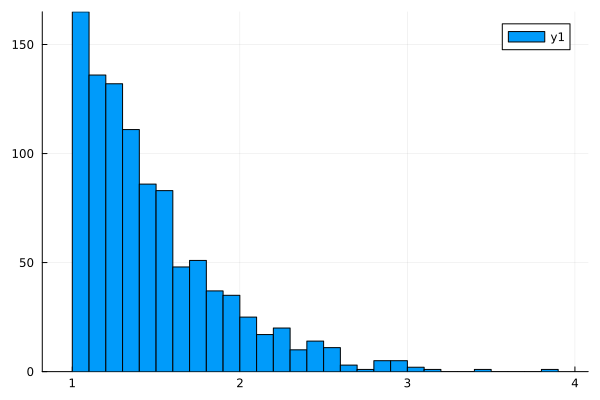

In [679]:
#### L shaped pleiotropy disribution #######

a = 1; b = 10
n_traits = 5 ## Number of traits 

n_genes = 1000
pleis = n_traits*rand(Beta(a, b) , n_genes).+1
histogram(pleis)



In [834]:
##### this function accepts a trait vector "trait" and returns a mutated trait vector and the pleiotropy of the mutation
##### parameters: "a", "b": paramters of the L and rev L shaped distributions; n_traits: total number of fitness determining traits; 
##### dist: distribution of pleiotropy ("L", "rev L" or "uni"); scaled: decides whether mutational effect is to be scaled with the pleiotropy ("1") or not ("0")

function mutate(trait,a,b, n_traits, dist, scaled) ### assuming many genes so mutations don't occur in the same gene again
    mtrait = zeros(Float64, n_traits)
    mtrait .= trait
    if dist == "L"
        plei = Int(round(n_traits*rand(Beta(a, b))+1)) ### randomly sample a plei -- these many traits will be affected by mutations 
    elseif dist == "rev L"
        plei = n_traits - Int(round(n_traits*rand(Beta(a, b))))
    elseif dist == "uni"
        plei = Int(round(n_traits*rand(Uniform(0,1))+1))
    end
    
    
    muts = rand(collect(1:1:n_traits), plei) #### randonly sampling "plei" traits that are affected -- mostly plei is 1

   
    
    for i in muts
        if scaled == 0
            effect = rand(Normal(0,1)) ### effect size of mutations is not scaled by plei 
            mtrait[i]+=effect
        elseif scaled ==1
            effect = plei*rand(Normal(0,1)) ### effect size of mutations is scaled by plei -- more plei have larger effect size 
            mtrait[i]+=effect
        end
            
    end

    return(mtrait, plei)   
end


mutate (generic function with 4 methods)

In [836]:
#### SSWM regime  #####
T = 200000


for dist in ["uni", "L", "uni"] ##### pleiotropy distribution
    println(dist)
    for n_traits in [20] #### number of fitness determining traits 
        println("n_traits = $n_traits")
        for N in [10,100,1000] ##### population size
            println("N = $N")
            trait = zeros(Float64, n_traits)#zeros(Float64, n_traits)
            trait_optima = ones(Float64, n_traits)
            
            
            a=1; b =10
            
            sigma = n_traits
            
            ps = []; fs = []; all_ps = []
            for i in collect(1:1:T)
              
                f1 = exp(-(norm(trait-trait_optima))^2/sigma^2)
                
                mm = mutate(trait,a,b, n_traits, dist,scaled)
               
                
                mtrait = mm[1]
                plei = mm[2]
               all_ps = vcat(all_ps, plei)
                f2 = exp(-(norm(mtrait-trait_optima))^2/sigma^2)
                
                s = f2-f1
                #println(s)
                if s !=0
                    Pfix = (1-exp(-2*s))/(1-exp(-4*N*s))
                else
                    Pfix = 1/N
                end
            
                if rand()<Pfix
                    println("fixation")
                    trait .= mtrait
                    
                    ps = vcat(ps, plei)
                    fs = vcat(fs, f2)
                end
            
                
                
            end
                
            
            writedlm("/Users/msrivast/Desktop/pleiotropy/scaled_fitness_SSWM_fixed_plei_dist=$(dist)_ntraits=$(n_traits)_K=$(K)_L=$(L)_N=$(N)_T=$T.csv", ps)
            writedlm("/Users/msrivast/Desktop/pleiotropy/scaled_fitness_SSWM_all_plei_dist=$(dist)_ntraits=$(n_traits)_K=$(K)_L=$(L)_N=$(N)_T=$T.csv", all_ps)
        end
    end
end

uni
n_traits = 20
N = 10
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fixation
fix

LoadError: InterruptException:

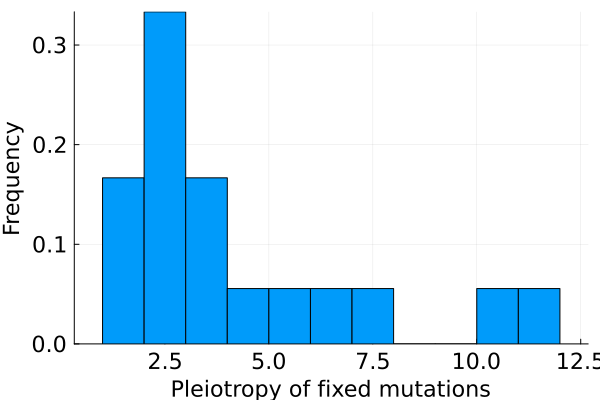

In [798]:
histogram(ps,normalize=:pdf, bins =15, xlabel = "pleiotropy", label=:false)
plot!(guidefontsize =15, tickfontsize =15, xlabel = "Pleiotropy of fixed mutations", ylabel = "Frequency")


In [416]:
savefig("/Users/msrivast/Desktop/pleiotropy/sswm_fixed_plei_ntraits=$(n_traits)_K=$(K)_L=$(L).pdf")

"/Users/msrivast/Desktop/pleiotropy/sswm_fixed_plei_ntraits=10_K=4_L=10.pdf"

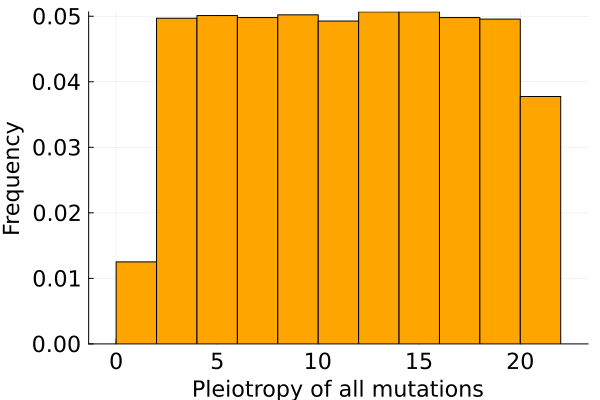

In [799]:

histogram(all_ps,normalize=:pdf, bins =15, fillcolor=:orange, label=:false)
plot!(guidefontsize =15, tickfontsize =15, xlabel = "Pleiotropy of all mutations", ylabel = "Frequency")

In [420]:
savefig("/Users/msrivast/Desktop/pleiotropy/sswm_all_plei_ntraits=$(n_traits)_K=$(K)_L=$(L).pdf")

"/Users/msrivast/Desktop/pleiotropy/sswm_all_plei_ntraits=10_K=4_L=10.pdf"

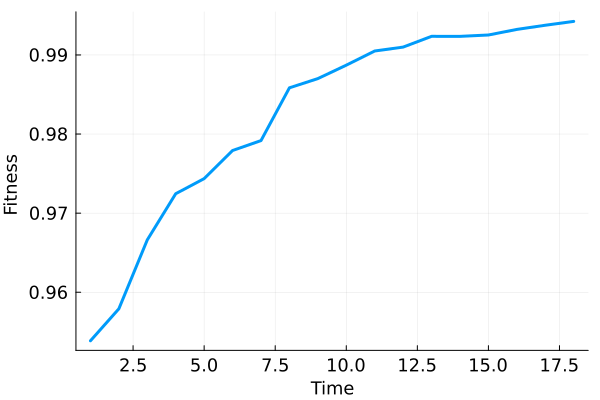

In [805]:
##### plotting the fitness as a function of time
plot(fs, xlabel = "Time", ylabel = "Fitness ", label=:false, linewidth = 3,guidefontsize =12, tickfontsize =12)

In [ ]:
#### greeedy regime #####

T = 10000

K =4; L = 10

a=1; b =10

sigma = 1000




for dist in ["L", "uni", "rev L"]
  println(dist)
    for n_traits in [20]#[5, 10, 15, 20]
            println("n_traits = $n_traits")
            trait = zeros(Float64, n_traits)#zeros(Float64, n_traits)
            mtrait = zeros(Float64, n_traits)
            trait_optima = ones(Float64, n_traits).+500
            ps = []; fs = []; all_ps = [];  pleis = []; mtraits = Array{Any,2}(undef,0,n_traits)
            #for i in collect(1:1:T)
            t=1
            while length(fs)<2 || fs[end]-fs[end-1]>0.000001 && t<T
                t+=1
              
                f1 = exp(-(norm(trait-trait_optima))^2/sigma^2)
                
               
               #all_ps = vcat(all_ps, plei)
                f2s = [];  mtrait.= trait
                        plei = 0
                for i in collect(1:1:(K-1)*L)
               
                    mm = mutate(trait,a,b, n_traits, dist, scaled)
                    mtraits = vcat(mtraits,transpose(mm[1]))
                    pleis = vcat(pleis,mm[2])
                    f2s = vcat(f2s,exp(-(norm(mm[1]-trait_optima))^2/sigma^2))
                    all_ps = vcat(all_ps, mm[2])
                    if f2s[end]>=maximum(f2s)
                        mtrait = mm[1]
                        plei = mm[2]
                    end
                end
                #println(mtraits)
                f2 = maximum(f2s)
               
                #plei = pleis[argmax(f2s)]
                #mtrait = mtraits[argmax(f2s)]
            
                
                if f2>=f1#rand()<Pfix
                    trait .= mtrait
                    
                    ps = vcat(ps, plei)
                    fs = vcat(fs, f2)
                end
            
                
                
            end
            writedlm("/Users/msrivast/Desktop/pleiotropy/scaled=$(scaled)_fitness_greedy_fixed_plei_dist=$(dist)_ntraits=$(n_traits)_K=$(K)_L=$(L)_T=$T.csv", ps)
            writedlm("/Users/msrivast/Desktop/pleiotropy/scaled=$(scaled)_fitness_greedy_all_plei_dist=$(dist)_ntraits=$(n_traits)_K=$(K)_L=$(L)_T=$T.csv", all_ps)
      
    end
end

L


4.269590222861251


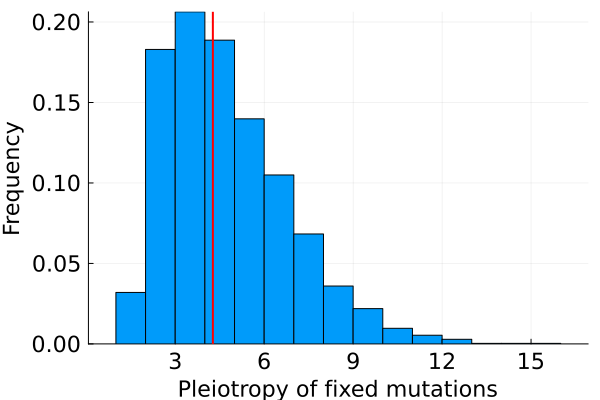

In [821]:
histogram(ps,normalize=:pdf, bins =15, xlabel = "pleiotropy", label=:false)
plot!(guidefontsize =15, tickfontsize =15, xlabel = "Pleiotropy of fixed mutations", ylabel = "Frequency")
println(mean(ps))
vline!([mean(ps)], linecolor=:red, linewidth =2, label=:false )

In [440]:
savefig("/Users/msrivast/Desktop/pleiotropy/greedy_fixed_plei_ntraits=$(n_traits)_K=$(K)_L=$(L).pdf")

"/Users/msrivast/Desktop/pleiotropy/greedy_fixed_plei_ntraits=10_K=4_L=10.pdf"

2.8035466091540857


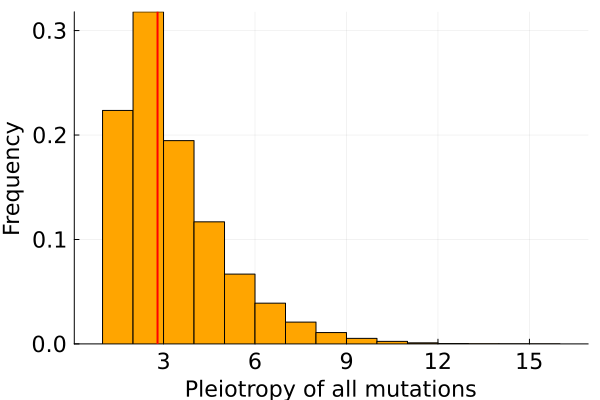

In [822]:
histogram(all_ps,normalize=:pdf, bins =15, fillcolor=:orange, label=:false)
plot!(guidefontsize =15, tickfontsize =15, xlabel = "Pleiotropy of all mutations", ylabel = "Frequency")
println(mean(all_ps))
vline!([mean(all_ps)], linecolor=:red, linewidth =2 , label=:false)

In [442]:
savefig("/Users/msrivast/Desktop/pleiotropy/greedy_all_plei_ntraits=$(n_traits)_K=$(K)_L=$(L).pdf")

"/Users/msrivast/Desktop/pleiotropy/greedy_all_plei_ntraits=10_K=4_L=10.pdf"

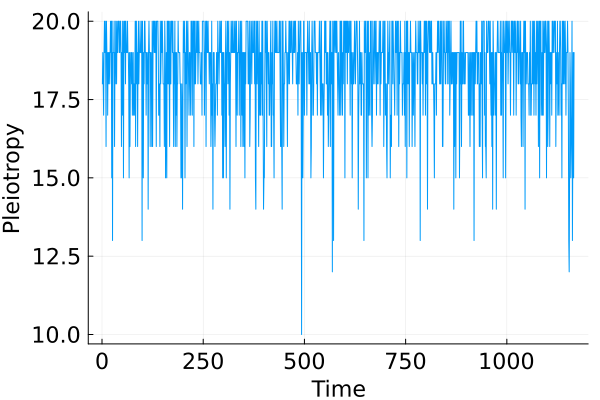

In [816]:
plot(ps, xlabel = "Time", ylabel = "Pleiotropy", label=:false)
plot!(guidefontsize =15, tickfontsize =15)

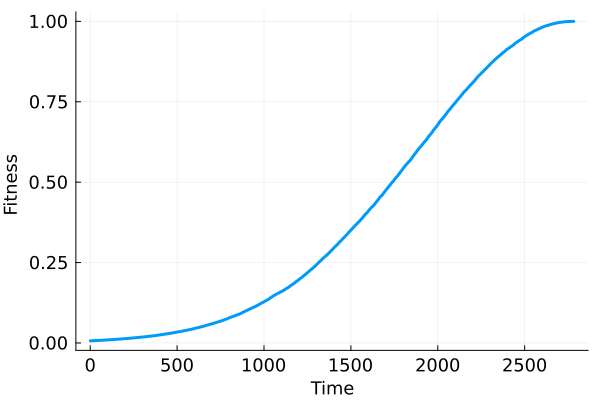

In [823]:
##### plotting the fitness as a function of time
plot(fs, xlabel = "Time", ylabel = "Fitness ", label=:false, linewidth = 3,guidefontsize =12, tickfontsize =12)